In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, average_precision_score,precision_recall_curve
import joblib
from sklearn.model_selection import RandomizedSearchCV

In [9]:
df = pd.read_csv("../data/creditcard.csv")
df["LogAmount"] = np.log1p(df["Amount"])

X = df.drop(["Class", "Amount"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
#Optimized parameters based on RandomizedSearchCV
#Best Parameters: 
# {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 800, 'min_child_samples': 50,
#  'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
model = lgb.LGBMClassifier(
    n_estimators=800,
    max_depth=15,
    num_leaves=63,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_samples=50,
    learning_rate=0.01,
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

# param_dist = {
#     "n_estimators": [200, 400, 600, 800],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "max_depth": [-1, 5, 10, 15],
#     "num_leaves": [15, 31, 63, 127],
#     "subsample": [0.7, 0.8, 0.9, 1.0],
#     "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
#     "min_child_samples": [10, 20, 50, 100]
# }

# search = RandomizedSearchCV(
#     estimator=model,
#     param_distributions=param_dist,
#     n_iter=30,
#     scoring="average_precision",   # optimise AUPRC
#     cv=3,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

In [10]:
#search.fit(X_train, y_train)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038205 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.01, max_depth=15,
               min_child_samples=50, n_estimators=800, n_jobs=-1, num_leaves=63,
               objective='binary', random_state=42,
               scale_pos_weight=577.2868020304569)

In [4]:
model = joblib.load("../models/lightgbm.pkl")

In [11]:
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:,1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auprc = average_precision_score(y_test, y_scores)

print("Precision:", precision)
print("Recall:", recall)
print("AUPRC:", auprc)

Precision: 0.898876404494382
Recall: 0.8163265306122449
AUPRC: 0.8544982148785429


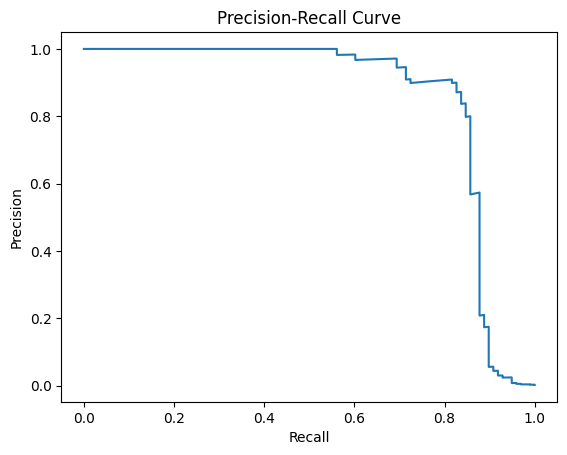

In [6]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

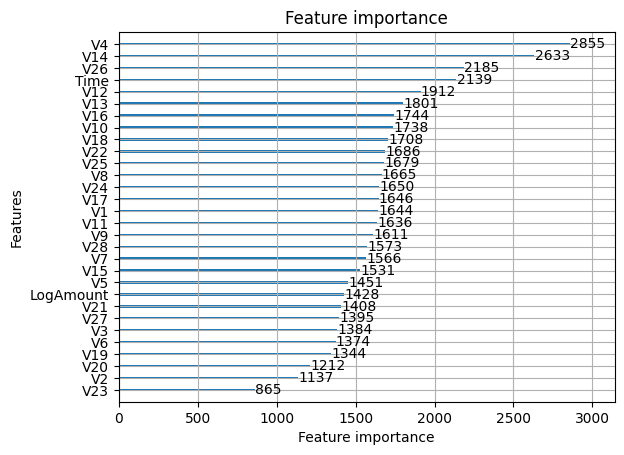

In [7]:
lgb.plot_importance(model)
plt.show()

In [8]:
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

f1 = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[f1.argmax()]

print(best_threshold)

y_pred_opt = (y_scores >= best_threshold).astype(int)

precision = precision_score(y_test, y_pred_opt)
recall = recall_score(y_test, y_pred_opt)

print("Precision:", precision)
print("Recall:", recall)

0.34312651917548204
Precision: 0.9
Recall: 0.826530612244898


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

print("AUPRC per fold:", scores)
print("Mean AUPRC:", scores.mean())

AUPRC per fold: [0.83098839 0.88798026 0.85491483 0.86193902 0.82314273]
Mean AUPRC: 0.8517930447866249
